# Random Forest Regression for Crop Yield Prediction

This notebook implements a Random Forest Regressor for predicting crop yield.

The workflow includes:
- Dataset loading
- Data preprocessing
- Train-test split
- Random Forest model training
- Prediction
- Model evaluation using MAE, MSE, RMSE and R²
- Actual vs Predicted visualization
- Residual analysis
- Feature importance analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv(
    r"C:\Crop Yield Prediction\data\Crop Yield Data.csv"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (19689, 13)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


In [6]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate removal:", df.shape)

Number of duplicate records: 0
Shape after duplicate removal: (19689, 13)


In [22]:
print("========== MISSING VALUE ANALYSIS ==========")

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

========== MISSING VALUE ANALYSIS ==========
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    2
Fertilizer         2
Pesticide          2
Yield              1
Avg_Temperature    2
Max_Temperature    0
Min_Temperature    0
dtype: int64

Total missing values: 9


In [24]:
print("Missing Yield values before removal:",
      df["Yield"].isnull().sum())

df = df.dropna(subset=["Yield"]).reset_index(drop=True)

print("Missing Yield values after removal:",
      df["Yield"].isnull().sum())

print("Dataset shape after removing missing Yield:",
      df.shape)

Missing Yield values before removal: 1
Missing Yield values after removal: 0
Dataset shape after removing missing Yield: (19688, 13)


## Feature Selection

The target variable is `Yield`.

The `Production` feature is excluded from model inputs because production is directly related to crop yield and cultivated area. Using Production as an input can introduce target leakage and produce unrealistically strong model performance.

The `id` column is also excluded because it is an identifier and does not represent an agricultural factor affecting yield.

In [26]:
# Remove target and leakage-related column

X = df.drop(
    ["Yield", "Production"],
    axis=1
)

y = df["Yield"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used for Random Forest:")
print(X.columns.tolist())

Features shape: (19688, 11)
Target shape: (19688,)

Features used for Random Forest:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']


In [27]:
print("Missing values in target:", y.isnull().sum())

if y.isnull().sum() == 0:
    print("Target variable is ready for model training.")
else:
    print("Warning: Target still contains missing values.")

Missing values in target: 0
Target variable is ready for model training.


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (15750, 11)
Testing data shape: (3938, 11)
Training target shape: (15750,)
Testing target shape: (3938,)


In [32]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']

Categorical Features:
['Crop', 'Season', 'State']


C:\Users\Manisha\AppData\Local\Temp\ipykernel_20516\2487196616.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [33]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numerical preprocessing pipeline created!")

Numerical preprocessing pipeline created!


In [34]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print("Categorical preprocessing pipeline created!")

Categorical preprocessing pipeline created!


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [36]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training data processed successfully!")
print("Testing data processed successfully!")

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Training data processed successfully!
Testing data processed successfully!

Processed training shape: (15750, 99)
Processed testing shape: (3938, 99)


## Random Forest Model

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees.

The model parameters used for the baseline model are:

- Number of trees (`n_estimators`) = 100
- Random state = 42
- Number of CPU cores (`n_jobs`) = -1

In [18]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [37]:
print("Starting Random Forest training...")

rf_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully!")
print("Number of trees:", len(rf_model.estimators_))

Starting Random Forest training...
Random Forest model trained successfully!
Number of trees: 100


In [38]:
rf_predictions = rf_model.predict(
    X_test_processed
)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(rf_predictions[:10])

Predictions generated successfully!

First 10 predictions:
[ 0.19897  0.2603  12.11557  1.13114  0.7414   0.2815   1.09205  0.52175
 79.04493  0.47386]


In [39]:
rf_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [40]:
rf_predictions = rf_model.predict(X_test_processed)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(rf_predictions[:10])

Predictions generated successfully!

First 10 predictions:
[ 0.19897  0.2603  12.11557  1.13114  0.7414   0.2815   1.09205  0.52175
 79.04493  0.47386]


In [41]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_mse = mean_squared_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("========== RANDOM FOREST RESULTS ==========")

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

========== RANDOM FOREST RESULTS ==========
MAE : 11.588271422041652
MSE : 23237.085144497374
RMSE: 152.4371514575675
R²  : 0.9671132070577182


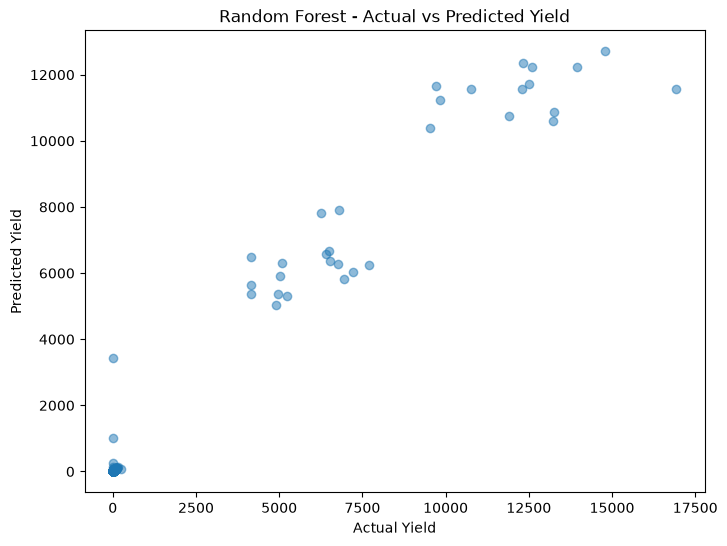

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest - Actual vs Predicted Yield")

plt.show()

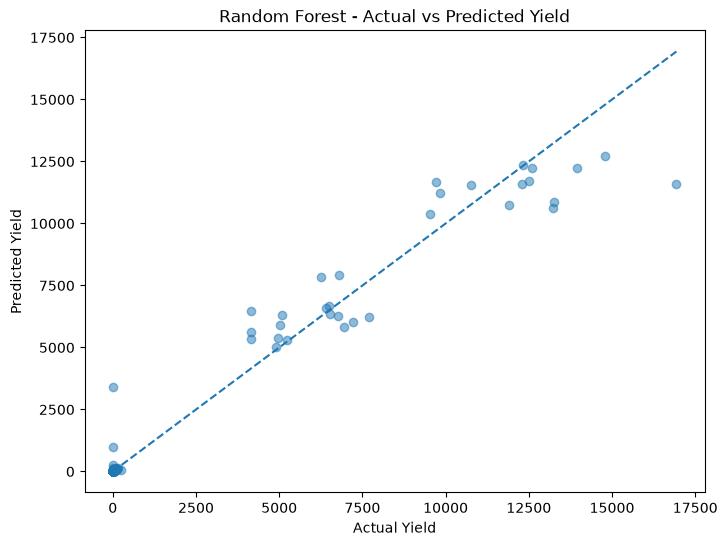

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5
)

min_value = min(y_test.min(), rf_predictions.min())
max_value = max(y_test.max(), rf_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest - Actual vs Predicted Yield")

plt.show()

In [44]:
rf_residuals = y_test - rf_predictions

print("Residual statistics:")
print(pd.Series(rf_residuals).describe())

Residual statistics:
count    3938.000000
mean        0.123890
std       152.456459
min     -3416.675530
25%        -0.162467
50%        -0.017265
75%         0.118010
max      5354.158890
Name: Yield, dtype: float64


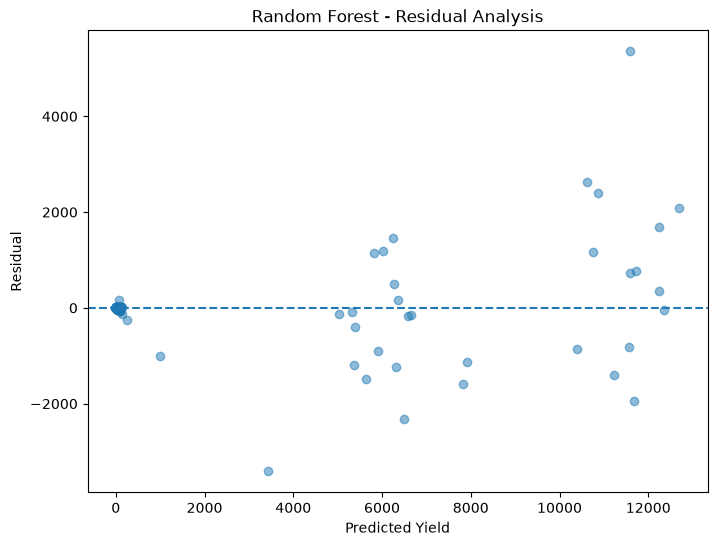

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rf_predictions,
    rf_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title("Random Forest - Residual Analysis")

plt.show()

In [46]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 20 processed features:")
print(feature_names[:20])

Number of processed features: 99

First 20 processed features:
['num__Crop_Year' 'num__Area' 'num__Annual_Rainfall' 'num__Fertilizer'
 'num__Pesticide' 'num__Avg_Temperature' 'num__Max_Temperature'
 'num__Min_Temperature' 'cat__Crop_Arecanut' 'cat__Crop_Arhar/Tur'
 'cat__Crop_Bajra' 'cat__Crop_Banana' 'cat__Crop_Barley'
 'cat__Crop_Black pepper' 'cat__Crop_Cardamom' 'cat__Crop_Cashewnut'
 'cat__Crop_Castor seed' 'cat__Crop_Coconut ' 'cat__Crop_Coriander'
 'cat__Crop_Cotton(lint)']


In [48]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("========== TOP 20 FEATURE IMPORTANCES ==========")

feature_importance.head(20)

========== TOP 20 FEATURE IMPORTANCES ==========


,Feature,Importance
17,cat__Crop_Coconut,0.848220
5,num__Avg_Temperature,0.036446
2,num__Annual_Rainfall,0.020721
1,num__Area,0.016814
4,num__Pesticide,0.016191
98,cat__State_West Bengal,0.013648
7,num__Min_Temperature,0.012003
73,cat__State_Chhattisgarh,0.008998
3,num__Fertilizer,0.006352
0,num__Crop_Year,0.005774


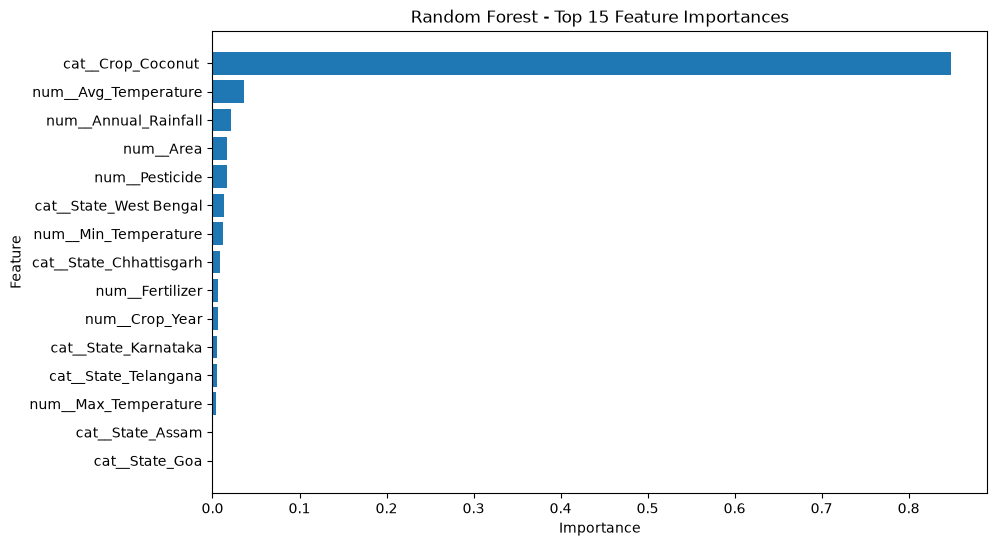

In [49]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Top 15 Feature Importances")

plt.show()

In [50]:
import joblib

joblib.dump(
    rf_model,
    r"C:\Crop Yield Prediction\models\random_forest_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [51]:
joblib.dump(
    preprocessor,
    r"C:\Crop Yield Prediction\models\preprocessor.pkl"
)

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


## Random Forest Model Conclusion

The Random Forest Regressor was successfully trained to predict crop yield.

The model was evaluated using MAE, MSE, RMSE, and R². An actual-versus-predicted plot was used to visually analyze prediction performance, while residual analysis was performed to examine prediction errors.

Feature importance was also analyzed to identify the processed features that contributed most to the Random Forest predictions.

The trained Random Forest model and preprocessing pipeline were saved for future use.